# Kalkulator kredytu — wizualizacja

Notatnik porównuje dwa schematy spłaty kredytu (**rata annuitetowa** vs **rata malejąca**) i pokazuje, jak prowizja wpływa na **RRSO**.

Zawartość:
1. Definicje funkcji
2. Parametry kredytu
3. Skład rat (kapitał vs odsetki)
4. Wysokość raty i kapitał pozostały w czasie
5. Skumulowane odsetki
6. Podsumowanie kosztów
7. Czułość RRSO na prowizję


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# styl
plt.rcParams.update({
    "figure.figsize": (11, 5),
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 10,
})

# kolory zarezerwowane dla schematów
KOLOR_ANN = "#2E86AB"   # annuitet  – niebieski
KOLOR_MAL = "#E07A5F"   # malejący  – pomarańczowy
KOLOR_KAP = "#90BE6D"   # kapitał   – zielony
KOLOR_ODS = "#F4A261"   # odsetki   – żółty

zl = FuncFormatter(lambda x, _: f"{x:,.0f} zł".replace(",", " "))
pp = FuncFormatter(lambda x, _: f"{x*100:.2f}%")


## 1. Funkcje obliczeniowe

In [2]:
def harmonogram_annuitetowy(kwota, oprocentowanie_roczne, liczba_rat):
    """Harmonogram z ratą równą (annuitetową)."""
    r, n, K = oprocentowanie_roczne / 12, liczba_rat, kwota
    rata = K / n if r == 0 else K * (r * (1 + r)**n) / ((1 + r)**n - 1)

    rows, pozostaly = [], K
    for i in range(1, n + 1):
        odsetki = pozostaly * r
        kapital = rata - odsetki
        pozostaly -= kapital
        rows.append({"Nr raty": i, "Rata": rata, "Kapitał": kapital,
                     "Odsetki": odsetki, "Kapitał pozostały": max(pozostaly, 0)})
    return pd.DataFrame(rows)


def harmonogram_malejacy(kwota, oprocentowanie_roczne, liczba_rat):
    """Harmonogram z ratą malejącą (stała część kapitałowa)."""
    r, n, K = oprocentowanie_roczne / 12, liczba_rat, kwota
    kap = K / n

    rows, pozostaly = [], K
    for i in range(1, n + 1):
        odsetki = pozostaly * r
        rata = kap + odsetki
        pozostaly -= kap
        rows.append({"Nr raty": i, "Rata": rata, "Kapitał": kap,
                     "Odsetki": odsetki, "Kapitał pozostały": max(pozostaly, 0)})
    return pd.DataFrame(rows)


def oblicz_rrso(kwota_kredytu, harmonogram, prowizja=0.0, inne_koszty=0.0):
    """RRSO wg dyrektywy 2008/48/WE – bisekcja."""
    raty = harmonogram["Rata"].to_numpy()
    t = np.arange(1, len(raty) + 1) / 12.0
    netto = kwota_kredytu - prowizja - inne_koszty

    def npv(X):
        return np.sum(raty / (1 + X)**t) - netto

    lo, hi = -0.999, 10.0
    f_lo, f_hi = npv(lo), npv(hi)
    if f_lo * f_hi > 0:
        raise ValueError("Brak zmiany znaku w przedziale.")
    for _ in range(200):
        mid = (lo + hi) / 2
        f_mid = npv(mid)
        if abs(f_mid) < 1e-10 or (hi - lo) < 1e-12:
            return mid
        if f_lo * f_mid < 0:
            hi, f_hi = mid, f_mid
        else:
            lo, f_lo = mid, f_mid
    return (lo + hi) / 2


## 2. Parametry kredytu

Zmień te wartości, żeby zobaczyć inny scenariusz – wszystkie wykresy poniżej
przeliczą się automatycznie.

In [3]:
KWOTA    = 100_000     # zł
OPROC    = 0.08        # 8% rocznie
RATY     = 60          # liczba rat miesięcznych
PROWIZJA = 3_000       # zł, pobierana z kwoty kredytu

h_ann = harmonogram_annuitetowy(KWOTA, OPROC, RATY)
h_mal = harmonogram_malejacy(KWOTA, OPROC, RATY)

rrso_ann = oblicz_rrso(KWOTA, h_ann, prowizja=PROWIZJA)
rrso_mal = oblicz_rrso(KWOTA, h_mal, prowizja=PROWIZJA)

print(f"Kredyt {KWOTA:,} zł na {RATY} mies. przy {OPROC*100:.2f}% i prowizji {PROWIZJA:,} zł\n")
print(f"  Annuitet :  rata stała = {h_ann['Rata'].iloc[0]:>10,.2f} zł"
      f"   suma odsetek = {h_ann['Odsetki'].sum():>10,.2f} zł"
      f"   RRSO = {rrso_ann*100:.4f}%")
print(f"  Malejący :  pierwsza  = {h_mal['Rata'].iloc[0]:>10,.2f} zł"
      f"   suma odsetek = {h_mal['Odsetki'].sum():>10,.2f} zł"
      f"   RRSO = {rrso_mal*100:.4f}%")
print(f"             ostatnia  = {h_mal['Rata'].iloc[-1]:>10,.2f} zł")


Kredyt 100,000 zł na 60 mies. przy 8.00% i prowizji 3,000 zł

  Annuitet :  rata stała =   2,027.64 zł   suma odsetek =  21,658.37 zł   RRSO = 9.7051%
  Malejący :  pierwsza  =   2,333.33 zł   suma odsetek =  20,333.33 zł   RRSO = 9.7918%
             ostatnia  =   1,677.78 zł


## 3. Skład rat — kapitał vs odsetki

Słupkowy wykres warstwowy: w każdym miesiącu pokazana jest część kapitałowa
(zielona) i odsetkowa (żółta). Łatwo zobaczyć, że w annuitecie **całkowita
wysokość raty się nie zmienia**, ale wewnątrz proporcja kapitał/odsetki
rośnie z czasem na korzyść kapitału. W ratach malejących to inaczej –
część kapitałowa jest stała, a całkowita rata maleje liniowo.

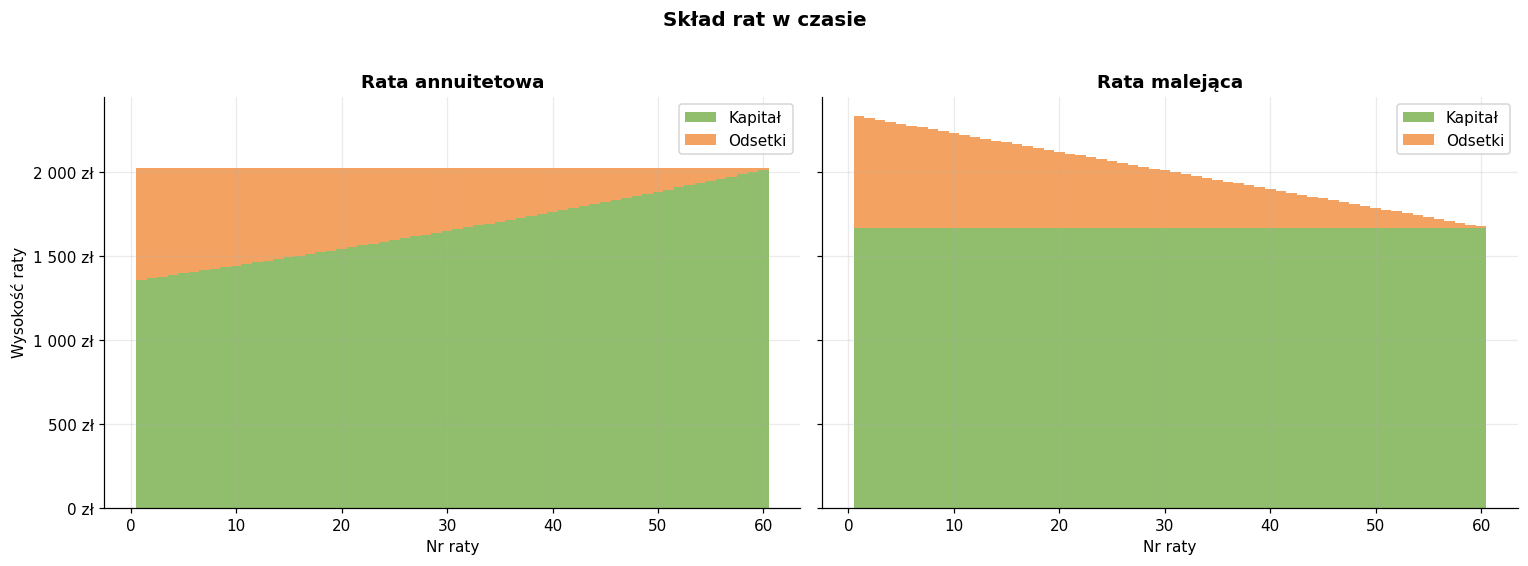

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, df, tytul in zip(axes, [h_ann, h_mal], ["Rata annuitetowa", "Rata malejąca"]):
    x = df["Nr raty"]
    ax.bar(x, df["Kapitał"], color=KOLOR_KAP, label="Kapitał", width=1.0)
    ax.bar(x, df["Odsetki"], bottom=df["Kapitał"], color=KOLOR_ODS,
           label="Odsetki", width=1.0)
    ax.set_title(tytul, fontsize=12, fontweight="bold")
    ax.set_xlabel("Nr raty")
    ax.yaxis.set_major_formatter(zl)
    ax.legend(loc="upper right")

axes[0].set_ylabel("Wysokość raty")
fig.suptitle("Skład rat w czasie", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


## 4. Wysokość raty i kapitał pozostały

Lewa strona pokazuje, jak zmienia się sama rata. Prawa – jak szybko spada
zadłużenie. **Rata malejąca początkowo bardziej obciąża budżet, ale
zadłużenie spada szybciej** (linia w prawym panelu jest niżej od annuitetu
przez większą część okresu).

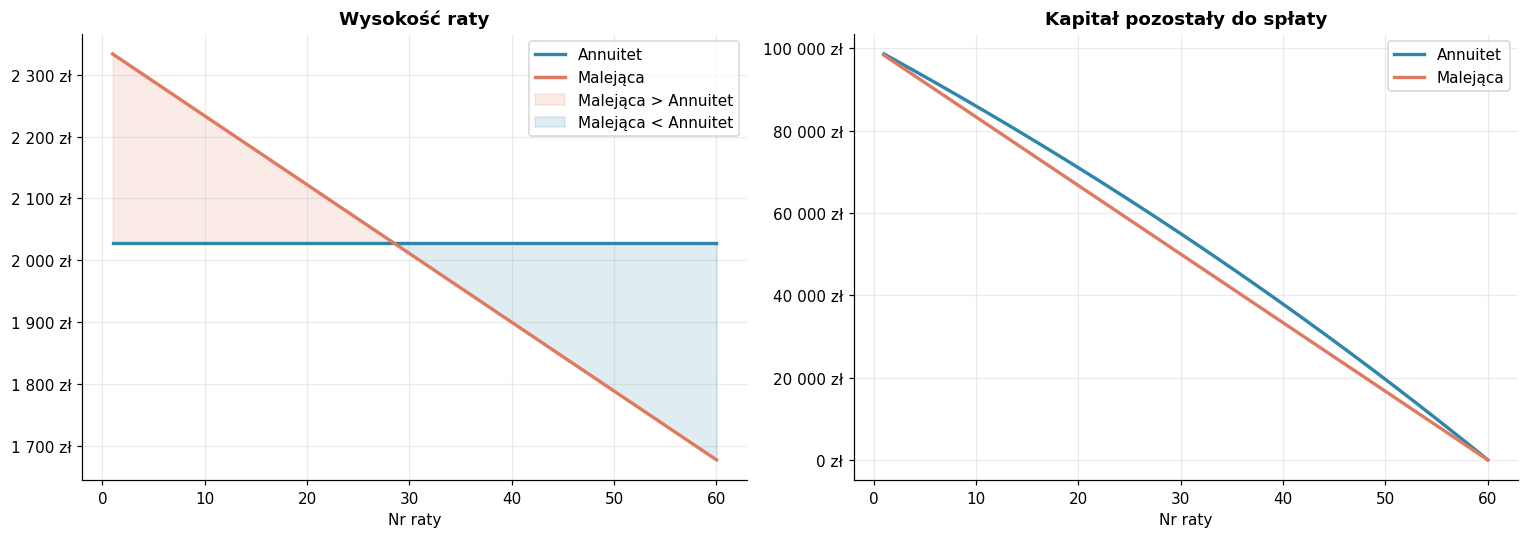

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) Wysokość raty
ax = axes[0]
ax.plot(h_ann["Nr raty"], h_ann["Rata"], color=KOLOR_ANN, lw=2.2, label="Annuitet")
ax.plot(h_mal["Nr raty"], h_mal["Rata"], color=KOLOR_MAL, lw=2.2, label="Malejąca")
ax.fill_between(h_mal["Nr raty"], h_ann["Rata"], h_mal["Rata"],
                where=(h_mal["Rata"] > h_ann["Rata"]), alpha=0.15, color=KOLOR_MAL,
                label="Malejąca > Annuitet")
ax.fill_between(h_mal["Nr raty"], h_ann["Rata"], h_mal["Rata"],
                where=(h_mal["Rata"] < h_ann["Rata"]), alpha=0.15, color=KOLOR_ANN,
                label="Malejąca < Annuitet")
ax.set_title("Wysokość raty", fontweight="bold")
ax.set_xlabel("Nr raty")
ax.yaxis.set_major_formatter(zl)
ax.legend()

# (b) Kapitał pozostały
ax = axes[1]
ax.plot(h_ann["Nr raty"], h_ann["Kapitał pozostały"], color=KOLOR_ANN, lw=2.2, label="Annuitet")
ax.plot(h_mal["Nr raty"], h_mal["Kapitał pozostały"], color=KOLOR_MAL, lw=2.2, label="Malejąca")
ax.set_title("Kapitał pozostały do spłaty", fontweight="bold")
ax.set_xlabel("Nr raty")
ax.yaxis.set_major_formatter(zl)
ax.legend()

plt.tight_layout()
plt.show()


## 5. Skumulowane odsetki

Najważniejszy wykres, gdy decydujemy o wyborze schematu. **Pole pomiędzy
liniami to dodatkowy koszt annuitetu** w porównaniu do raty malejącej.

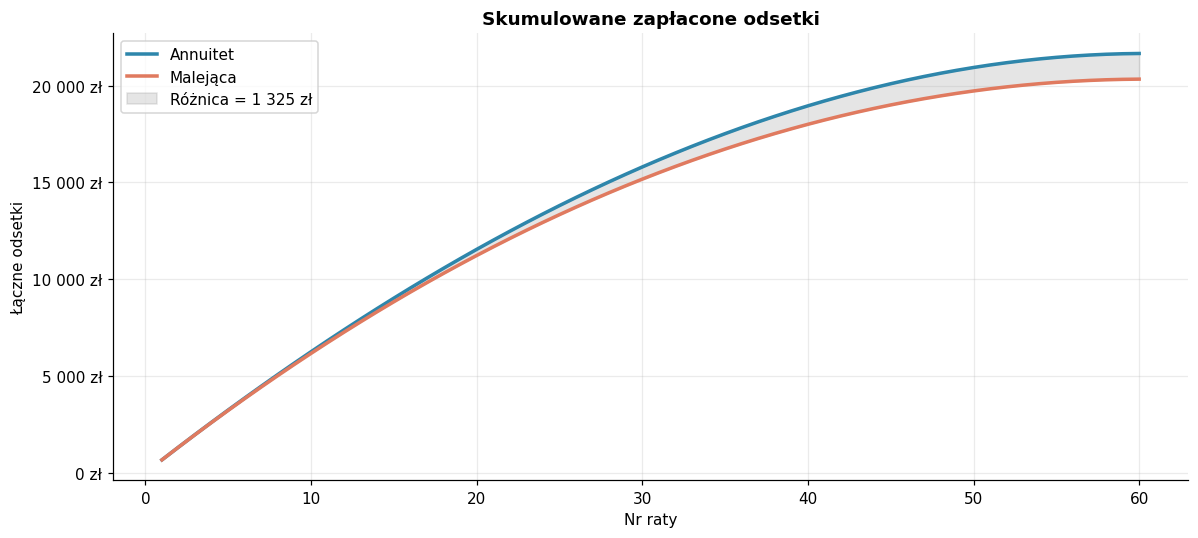

In [6]:
fig, ax = plt.subplots(figsize=(11, 5))

cum_ann = h_ann["Odsetki"].cumsum()
cum_mal = h_mal["Odsetki"].cumsum()

ax.plot(h_ann["Nr raty"], cum_ann, color=KOLOR_ANN, lw=2.3, label="Annuitet")
ax.plot(h_mal["Nr raty"], cum_mal, color=KOLOR_MAL, lw=2.3, label="Malejąca")
ax.fill_between(h_ann["Nr raty"], cum_mal, cum_ann, alpha=0.2, color="grey",
                label=f"Różnica = {(cum_ann.iloc[-1] - cum_mal.iloc[-1]):,.0f} zł".replace(",", " "))

ax.set_title("Skumulowane zapłacone odsetki", fontweight="bold", fontsize=12)
ax.set_xlabel("Nr raty")
ax.set_ylabel("Łączne odsetki")
ax.yaxis.set_major_formatter(zl)
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()


## 6. Podsumowanie całkowitych kosztów

Słupek = kapitał + odsetki + prowizja. Pokazuje, ile **łącznie** oddamy do banku.

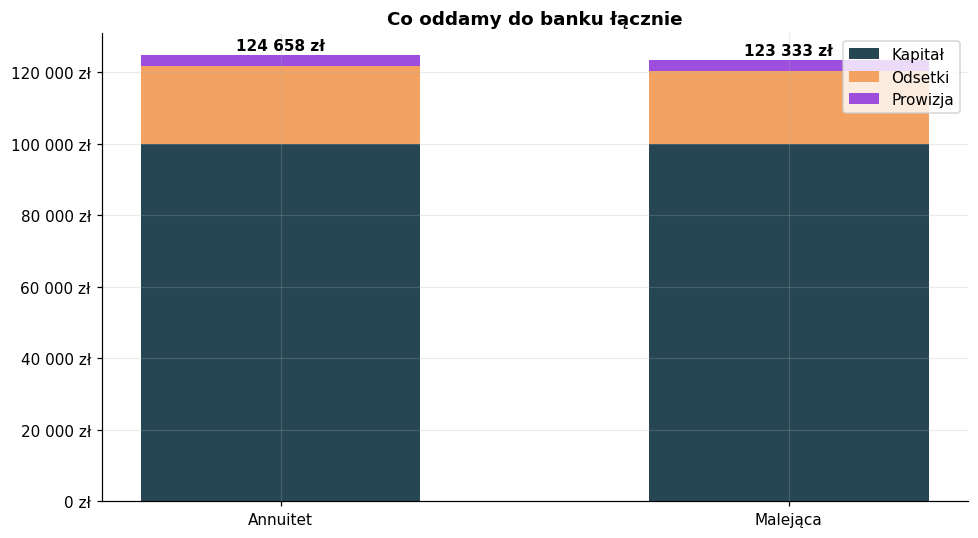


RRSO  annuitet: 9.7051%
RRSO  malejąca: 9.7918%


In [7]:
fig, ax = plt.subplots(figsize=(9, 5))

dane = pd.DataFrame({
    "Schemat":  ["Annuitet", "Malejąca"],
    "Kapitał":  [KWOTA, KWOTA],
    "Odsetki":  [h_ann["Odsetki"].sum(), h_mal["Odsetki"].sum()],
    "Prowizja": [PROWIZJA, PROWIZJA],
})

bottom = np.zeros(len(dane))
for kolumna, kolor in [("Kapitał", "#264653"),
                       ("Odsetki", KOLOR_ODS),
                       ("Prowizja", "#9D4EDD")]:
    ax.bar(dane["Schemat"], dane[kolumna], bottom=bottom, label=kolumna,
           color=kolor, width=0.55)
    bottom += dane[kolumna].values

# etykiety sum na wierzchu
for i, total in enumerate(bottom):
    ax.text(i, total + 1500, f"{total:,.0f} zł".replace(",", " "),
            ha="center", fontweight="bold")

ax.set_title("Co oddamy do banku łącznie", fontweight="bold", fontsize=12)
ax.yaxis.set_major_formatter(zl)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

print(f"\nRRSO  annuitet: {rrso_ann*100:.4f}%")
print(f"RRSO  malejąca: {rrso_mal*100:.4f}%")


## 7. Jak prowizja wpływa na RRSO

RRSO **nie zależy** wprost od wysokości raty (te dwa schematy mają podobne
RRSO przy tej samej prowizji), za to **bardzo silnie zależy od kosztów
upfront** — prowizji, ubezpieczenia, opłaty przygotowawczej. Poniższy
wykres pokazuje, jak RRSO rośnie wraz z prowizją w przedziale 0–10%
kwoty kredytu.

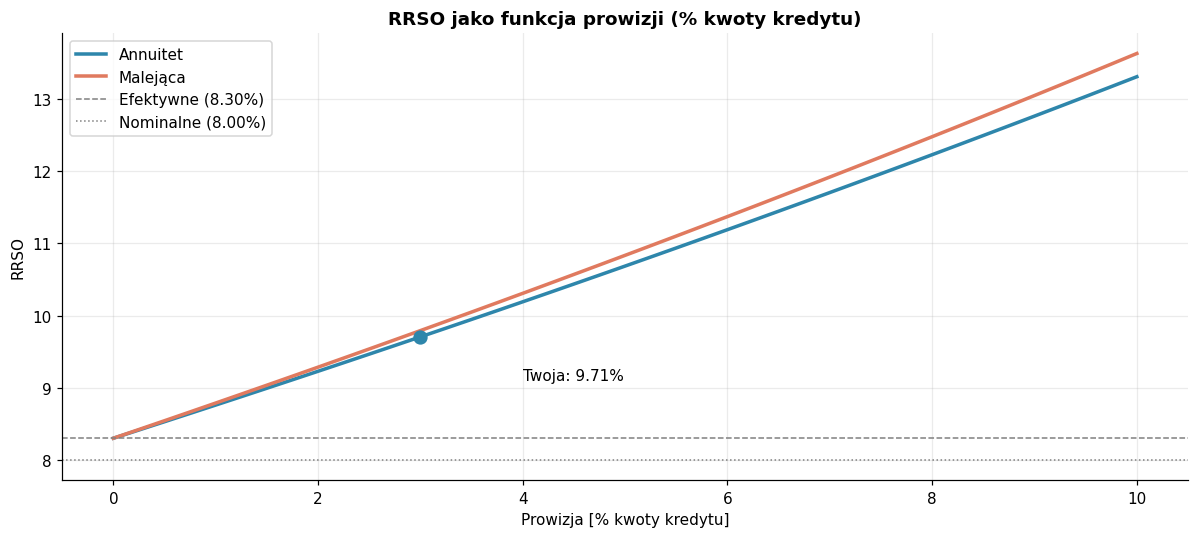

In [8]:
prow_proc = np.linspace(0, 0.10, 41)         # 0% do 10% kwoty kredytu
rrso_a = [oblicz_rrso(KWOTA, h_ann, prowizja=p*KWOTA) for p in prow_proc]
rrso_m = [oblicz_rrso(KWOTA, h_mal, prowizja=p*KWOTA) for p in prow_proc]

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(prow_proc*100, np.array(rrso_a)*100, color=KOLOR_ANN, lw=2.3, label="Annuitet")
ax.plot(prow_proc*100, np.array(rrso_m)*100, color=KOLOR_MAL, lw=2.3, label="Malejąca")

# linia odniesienia: oprocentowanie nominalne efektywne
efektywna = ((1 + OPROC/12)**12 - 1) * 100
ax.axhline(efektywna, color="grey", ls="--", lw=1, label=f"Efektywne ({efektywna:.2f}%)")
ax.axhline(OPROC*100, color="grey", ls=":", lw=1, label=f"Nominalne ({OPROC*100:.2f}%)")

# punkt referencyjny – nasza prowizja
ax.scatter([PROWIZJA/KWOTA*100], [rrso_ann*100], color=KOLOR_ANN, s=70, zorder=5)
ax.annotate(f"Twoja: {rrso_ann*100:.2f}%",
            xy=(PROWIZJA/KWOTA*100, rrso_ann*100),
            xytext=(PROWIZJA/KWOTA*100 + 1, rrso_ann*100 - 0.6),
            fontsize=10)

ax.set_title("RRSO jako funkcja prowizji (% kwoty kredytu)", fontweight="bold", fontsize=12)
ax.set_xlabel("Prowizja [% kwoty kredytu]")
ax.set_ylabel("RRSO")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()


## 8. Fragmenty harmonogramów

In [9]:
pd.options.display.float_format = "{:,.2f}".format

print("ANNUITET — pierwsze 5 rat:")
print(h_ann.head().to_string(index=False))
print("\nANNUITET — ostatnie 5 rat:")
print(h_ann.tail().to_string(index=False))

print("\n" + "="*65)
print("MALEJĄCY — pierwsze 5 rat:")
print(h_mal.head().to_string(index=False))
print("\nMALEJĄCY — ostatnie 5 rat:")
print(h_mal.tail().to_string(index=False))


ANNUITET — pierwsze 5 rat:
 Nr raty     Rata  Kapitał  Odsetki  Kapitał pozostały
       1 2,027.64 1,360.97   666.67          98,639.03
       2 2,027.64 1,370.05   657.59          97,268.98
       3 2,027.64 1,379.18   648.46          95,889.80
       4 2,027.64 1,388.37   639.27          94,501.43
       5 2,027.64 1,397.63   630.01          93,103.80

ANNUITET — ostatnie 5 rat:
 Nr raty     Rata  Kapitał  Odsetki  Kapitał pozostały
      56 2,027.64 1,961.38    66.26           7,977.16
      57 2,027.64 1,974.46    53.18           6,002.70
      58 2,027.64 1,987.62    40.02           4,015.08
      59 2,027.64 2,000.87    26.77           2,014.21
      60 2,027.64 2,014.21    13.43               0.00

MALEJĄCY — pierwsze 5 rat:
 Nr raty     Rata  Kapitał  Odsetki  Kapitał pozostały
       1 2,333.33 1,666.67   666.67          98,333.33
       2 2,322.22 1,666.67   655.56          96,666.67
       3 2,311.11 1,666.67   644.44          95,000.00
       4 2,300.00 1,666.67   633.33  